# 04 Modeling: Price Prediction

Objective: build regression models to predict Airbnb listing price.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.modeling import build_preprocessor
from src.evaluation import regression_metrics

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PROCESSED / "modeling_airbnb_athens.csv")

df.head()

,id,name,host_id,host_since,host_is_superhost,host_response_rate,host_acceptance_rate,host_identity_verified,neighbourhood_cleansed,latitude,...,review_scores_location,review_scores_value,reviews_per_month,has_reviews,instant_bookable,is_entire_home,host_experience_days,estimated_occupancy_l365d,estimated_revenue_l365d,high_price_listing
0,33945,Spacious Cosy aprtm very close to Metro!,146553,2010-06-17,0.0,100.0,84.0,1.0,ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ,38.00673,...,4.64,4.81,0.49,1,0,1,5855.0,128,5760.0,0
1,49489,Ermou 44 - 3bdr apt in the heart of Athens,225612,2010-09-06,0.0,100.0,100.0,1.0,ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,37.97670,...,4.89,4.69,0.83,1,1,1,5774.0,12,1920.0,1
2,60394,Cosy apartment! Great central Athens location!,290864,2010-11-18,1.0,NaN,100.0,1.0,ΣΤΑΔΙΟ,37.96738,...,4.92,4.92,0.29,1,0,1,5701.0,60,3000.0,0
3,154243,LUSCIOUS ROOF GARDEN IN THE CENTER!,741851,2011-06-25,0.0,60.0,77.0,1.0,ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ,37.98574,...,4.60,4.66,1.30,1,0,1,5482.0,84,5880.0,0
4,155654,"Acropolis Cosy Apartment, Koukaki",712602,2011-06-17,0.0,100.0,NaN,1.0,ΑΚΡΟΠΟΛΗ,37.96828,...,4.95,4.71,0.47,1,0,1,5490.0,0,0.0,0


In [8]:
df.shape

(14091, 45)

In [9]:
df["price"].isna().sum(), df["log_price"].isna().sum()

(np.int64(0), np.int64(0))

In [10]:
target = "log_price"

numeric_features = [
    col for col in [
        "accommodates", "bathrooms", "bedrooms", "beds", "amenities_count",
        "minimum_nights", "availability_365", "availability_rate",
        "number_of_reviews", "review_scores_rating", "reviews_per_month",
        "host_experience_days"
    ] if col in df.columns
]

categorical_features = [
    col for col in [
        "neighbourhood_cleansed", "property_type", "room_type",
        "host_is_superhost", "instant_bookable", "is_entire_home"
    ] if col in df.columns
]

model_df = df[numeric_features + categorical_features + [target]].dropna(subset=[target])
X = model_df[numeric_features + categorical_features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
preprocessor = build_preprocessor(numeric_features, categorical_features)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=10000),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    metrics = regression_metrics(y_test, preds)
    metrics["Model"] = name
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

,MAE,RMSE,R2,Model
3,0.255354,0.340102,0.610857,Random Forest
4,0.283367,0.364785,0.552321,Gradient Boosting
0,0.298909,0.387455,0.494949,Linear Regression
1,0.298820,0.387463,0.494928,Ridge
2,0.304388,0.396070,0.472241,Lasso


In [12]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

best_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

best_pipe.fit(X_train, y_train)
joblib.dump(best_pipe, MODELS_DIR / "best_price_model.pkl")

best_model_name

'Random Forest'

## Regression Model Results

The Random Forest Regressor achieved the best performance among the tested models, with the lowest RMSE and the highest R² score. The model explains approximately 61.1% of the variation in log-transformed Airbnb prices.

Tree-based models outperformed linear models, suggesting that Airbnb pricing in Athens is influenced by non-linear relationships and interactions between features such as neighbourhood, room type, property capacity, number of bedrooms, bathrooms and amenities.

Linear Regression and Ridge Regression produced almost identical results, while Lasso performed slightly worse. This indicates that regularisation did not substantially improve the linear model, probably because important price patterns are not purely linear.

Overall, Random Forest is selected as the best-performing regression model for price prediction.

In [13]:
results_df.to_csv(REPORTS_DIR / "regression_model_results.csv", index=False)

results_df

,MAE,RMSE,R2,Model
3,0.255354,0.340102,0.610857,Random Forest
4,0.283367,0.364785,0.552321,Gradient Boosting
0,0.298909,0.387455,0.494949,Linear Regression
1,0.298820,0.387463,0.494928,Ridge
2,0.304388,0.396070,0.472241,Lasso


In [14]:
# Create actual vs predicted table
y_pred_log = best_pipe.predict(X_test)

predictions_df = X_test.copy()
predictions_df["actual_log_price"] = y_test
predictions_df["predicted_log_price"] = y_pred_log

predictions_df["actual_price"] = np.expm1(predictions_df["actual_log_price"])
predictions_df["predicted_price"] = np.expm1(predictions_df["predicted_log_price"])

predictions_df["prediction_error"] = (
    predictions_df["actual_price"] - predictions_df["predicted_price"]
)

predictions_df.head()

,accommodates,bathrooms,bedrooms,beds,amenities_count,minimum_nights,availability_365,availability_rate,number_of_reviews,review_scores_rating,...,property_type,room_type,host_is_superhost,instant_bookable,is_entire_home,actual_log_price,predicted_log_price,actual_price,predicted_price,prediction_error
13639,4,1.0,1.0,2.0,60,1,336,0.920548,1,5.00,...,Entire rental unit,Entire home/apt,0.0,1,1,4.369448,4.546950,78.0,93.344211,-15.344211
9941,6,1.0,2.0,3.0,30,1,360,0.986301,7,4.71,...,Entire rental unit,Entire home/apt,0.0,1,1,3.988984,4.292612,53.0,72.157280,-19.157280
6743,16,3.0,6.0,14.0,38,1,154,0.421918,21,4.76,...,Entire rental unit,Entire home/apt,0.0,1,1,4.882802,5.361895,131.0,212.128392,-81.128392
11871,4,1.0,2.0,3.0,27,3,36,0.098630,27,4.96,...,Entire rental unit,Entire home/apt,NaN,1,1,4.204693,4.257264,66.0,69.616542,-3.616542
795,2,1.0,0.0,1.0,38,1,305,0.835616,0,NaN,...,Entire condo,Entire home/apt,0.0,1,1,3.912023,4.213057,49.0,66.562755,-17.562755


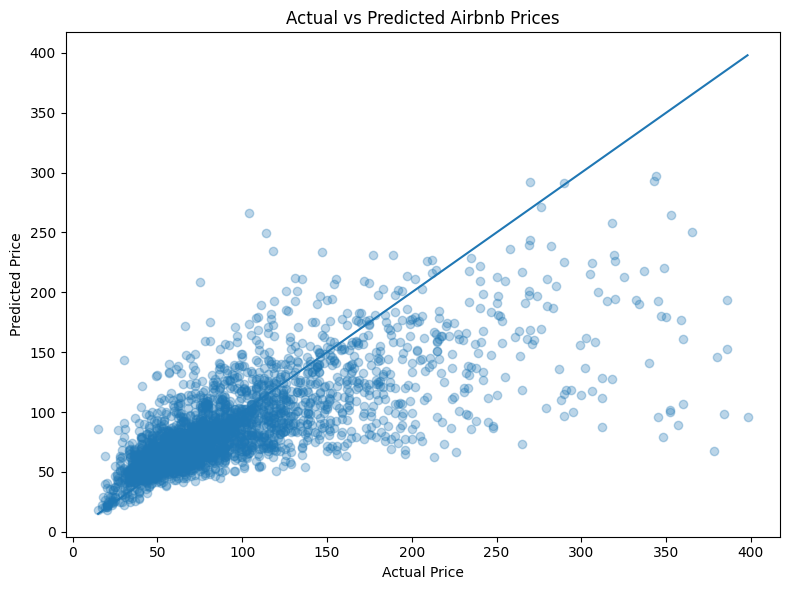

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(
    predictions_df["actual_price"],
    predictions_df["predicted_price"],
    alpha=0.3
)

plt.plot(
    [predictions_df["actual_price"].min(), predictions_df["actual_price"].max()],
    [predictions_df["actual_price"].min(), predictions_df["actual_price"].max()]
)

plt.title("Actual vs Predicted Airbnb Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "figures" / "actual_vs_predicted_price.png", dpi=300)
plt.show()

In [22]:
predictions_df.to_csv(
    DATA_PROCESSED / "price_predictions_airbnb_athens.csv",
    index=False
)

print("Prediction file saved successfully.")

Prediction file saved successfully.


In [24]:
# evaluate the model in euros
euro_metrics = {
    "MAE_euros": round(float(mean_absolute_error(
        predictions_df["actual_price"],
        predictions_df["predicted_price"]
    )), 3),
    
    "RMSE_euros": round(float(np.sqrt(
        mean_squared_error(
            predictions_df["actual_price"],
            predictions_df["predicted_price"]
        )
    )), 3),
    
    "R2_euros": round(float(r2_score(
        predictions_df["actual_price"],
        predictions_df["predicted_price"]
    )), 3)
}

euro_metrics

{'MAE_euros': 25.329, 'RMSE_euros': 41.561, 'R2_euros': 0.515}

## Model Error in Euro Terms

Because the model was trained on log-transformed prices, the main comparison between models is based on log-price metrics. To make the results easier to interpret from a business perspective, predictions were transformed back into euro prices.

The euro-based error metrics show the average prediction error in nightly price terms. These values are useful for communicating the model results to non-technical audiences and for integrating the predictions into the Power BI dashboard.

In [25]:
import json

with open(REPORTS_DIR / "regression_euro_metrics.json", "w") as f:
    json.dump(euro_metrics, f, indent=4)

print("Euro metrics saved successfully.")

Euro metrics saved successfully.


## Business Interpretation of Regression Results

After converting the log-price predictions back into euros, the Random Forest model achieves a mean absolute error of approximately €25.329. This means that, on average, the model's predicted nightly price differs from the actual listing price by about €25.

The RMSE is approximately €41.561, indicating that larger errors exist for some listings, especially for higher-priced or unusual properties. The euro-based R² is 0.515, meaning that the model explains about 51.5% of the variation in actual nightly prices after predictions are transformed back into euros.

These results are acceptable for a real-world Airbnb pricing problem, where prices are influenced by many unobserved factors such as interior quality, seasonality, photos, exact location attractiveness, view, renovation status and host pricing strategy.

## Notebook 04 Summary

The regression modeling stage compared linear and tree-based machine learning models for predicting Airbnb listing prices in Athens. The Random Forest model achieved the best performance, explaining approximately 61% of the variance in log-transformed prices.

The results suggest that Airbnb prices are affected by non-linear relationships between location, room type, property capacity, amenities and host/listing characteristics. The prediction outputs were saved for later use in the Power BI dashboard and final presentation.